# W2D2 — Looking at the Data — Lab

**Week 2 · Day 2 · Data Engineering & Preprocessing** · Lab

Five charts. **Each one has to change a decision you would otherwise have made wrongly.** A chart
that changes nothing is decoration, and this lab does not accept decoration — every chart you make
today is paired with one written sentence saying what you now believe that you did not believe
before.

The deliverable is not the picture. It is the sentence.

You already ranked the columns numerically at the end of yesterday's lab. Today you find out whether
that ranking survives being looked at. One of the five charts will show you that a feature you
engineered yesterday is almost an exact copy of a column you already had.

You'll leave with `charts/` and `eda_findings.md`.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٢ اليوم ٢ — النظر في البيانات

**الأسبوع ٢ · اليوم ٢ · هندسة البيانات والمعالجة المسبقة** · معمل عملي

خمسة رسوم. **على كل رسم أن يغيّر قرارًا كنت ستتّخذه خطأً بدونه.** فالرسم الذي لا يغيّر شيئًا زخرفة،
وهذا المعمل لا يقبل الزخرفة: فكل رسم تصنعه اليوم مقترن بجملة مكتوبة واحدة تقول ما صرت تعتقده الآن ولم
تكن تعتقده قبله.

والمُنتَج المطلوب ليس الصورة بل الجملة.

وقد رتّبت الأعمدة رقميًا في نهاية معمل الأمس، واليوم تكتشف هل يبقى هذا الترتيب صحيحًا بعد النظر. وسيُظهر
لك أحد الرسوم الخمسة أن خاصية هندستها بالأمس نسخة تكاد تكون مطابقة لعمود كان لديك أصلًا.

ستخرج بمجلّد `charts/` وملف `eda_findings.md`.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Choose the right chart for a question: histogram, box plot, bar chart, heatmap, scatter.
- Read a distribution and say what its mean alone would have hidden from you.
- Read a correlation heatmap, and spot two columns that carry the same information.
- Write the finding a chart supports as one sentence, in the units of the problem.
- Label a chart so that someone who was not in the room can read it — axes with units, and a title
  that states the finding rather than the variable names.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- اختيار الرسم المناسب للسؤال: المدرّج التكراري، ومخطّط الصندوق، والأعمدة، والخريطة الحرارية، والانتشار.
- قراءة توزيع وبيان ما كان متوسطه وحده سيُخفيه عنك.
- قراءة خريطة الارتباط الحرارية، واكتشاف عمودين يحملان المعلومة نفسها.
- كتابة النتيجة التي يدعمها الرسم في جملة واحدة، بوحدات المسألة نفسها.
- تسمية الرسم بحيث يقرأه من لم يكن في القاعة: محاور بوحداتها، وعنوان يذكر النتيجة لا أسماء المتغيّرات.

</div>

## About the data

**Dataset:** `telco_churn`, via **yesterday's `features.parquet`** — 7,043 rows × 25 columns

This is not the raw file. It is the feature table you built in W2D1: `TotalCharges` already converted
to a number with its eleven zero-tenure customers filled, `churn_flag` as 0/1, `contract_months` from
the lookup you merged, plus the two columns you engineered — `avg_monthly_spend` and `tenure_bucket`.

If you did not finish yesterday, `load_artefact` falls back to the reference copy in
`shared/solutions_cache/` and prints a note saying so. You are not blocked.

The target is still `Churn`, and it is still imbalanced: **26.5% churned**. The first chart you make
today puts that number in front of you, because every accuracy score you read for the rest of the
bootcamp has to be compared against the 73.5% you get by predicting "No" every time.

**Watch out:** two of the numeric columns in this table are almost the same column. Chart 3 finds
them. Until then, do not assume that a feature you engineered added information just because it added
a column.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `telco_churn` عبر ملف **الأمس `features.parquet`** — ٧٬٠٤٣ صفًا × ٢٥ عمودًا

هذا ليس الملف الخام، بل جدول الخصائص الذي بنيته في اليوم الأول: العمود `TotalCharges` محوَّل إلى رقم
وعملاؤه الأحد عشر ذوو المدّة صفر مملوءون، والعمود `churn_flag` بقيم ٠ و١، والعمود `contract_months` من
جدول البحث الذي دمجته، مع العمودين الذين هندستهما `avg_monthly_spend` و`tenure_bucket`.

وإن لم تُكمل الأمس فإن `load_artefact` ترجع إلى النسخة المرجعية في `shared/solutions_cache/` وتطبع
ملاحظة بذلك، فأنت غير متعطّل.

والهدف ما زال `Churn` وما زال غير متوازن: **٢٦٫٥٪ غادروا**. وأول رسم تصنعه اليوم يضع هذا الرقم أمامك،
لأن كل قيمة دقة تقرأها في بقية المعسكر يجب أن تُقارن بنسبة ٧٣٫٥٪ التي تحصل عليها بقول «لا» في كل مرة.

**انتبه:** عمودان من الأعمدة الرقمية في هذا الجدول يكادان يكونان عمودًا واحدًا، ويجدهما الرسم الثالث.
وحتى ذلك الحين، لا تفترض أن الخاصية التي هندستها أضافت معلومة لمجرّد أنها أضافت عمودًا.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, and loads yesterday's
artefact — falling back to the reference copy if you do not have your own.

**A note on Arabic in charts:** every axis label, title and legend in this notebook is in **English**.
Matplotlib cannot shape Arabic script without extra fonts, and when it fails it fails *silently* —
you get disconnected letters running the wrong way, and it looks like your data is broken. So the
Arabic explanation of each chart goes in the markdown above it, and never inside the figure. See
`docs/Bilingual_Style_Guide.md` §8.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتُحمّل مخرجات الأمس — مع الرجوع
إلى النسخة المرجعية إن لم تكن لديك نسختك.

**ملاحظة عن العربية في الرسوم:** كل تسمية محور وعنوان ووسيلة إيضاح في هذا الدفتر **بالإنجليزية**. فلا
تستطيع matplotlib تشكيل الحرف العربي دون خطوط إضافية، وعندما تفشل تفشل **بصمت**: فتظهر حروف مفكّكة
بالاتجاه الخاطئ، ويبدو الأمر كأن بياناتك معطوبة. فيوضع الشرح العربي لكل رسم في خلية الشرح فوقه، ولا
يوضع داخل الصورة أبدًا. راجع القسم الثامن من `docs/Bilingual_Style_Guide.md`.

</div>

In [3]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import load_artefact
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("matplotlib", "pyarrow")
seed_everything(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aiep.viz import use_course_style, PALETTE, savefig
use_course_style()

df = pd.read_parquet(load_artefact("features.parquet"))

# Every chart goes here, and the findings file next to it.
CHARTS = ARTEFACT_DIR / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

# Filled in as you go: chart name -> the Axes object. The sanity check at the end reads
# the labels back off these, so an unlabelled axis fails the lab rather than shipping.
AXES = {}

print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"churn rate: {df['churn_flag'].mean():.1%}")
print("\n", versions())

ℹ️  Using the reference copy of features.parquet from solutions_cache (you don't have a local one yet).
   نستخدم النسخة المرجعية من features.parquet لعدم وجود نسخة محلية لديك.
7,043 rows x 25 columns
churn rate: 26.5%

 python 3.11.16 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0+cpu | transformers 5.15.1


## Section 1 — Warm-up: bins are a choice, not a fact  (≈25 min)

Both charts below already work. Run them, then **change one number** and watch the story change.

The histogram bins `tenure`. A bin count is not a property of your data — it is a decision you made,
and it decides what the reader sees. Too few bins and every distribution looks like one smooth hill.
Too many and noise looks like structure.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: عدد الفئات قرار لا حقيقة (نحو ٢٥ دقيقة)

الرسمان أدناه يعملان أصلًا. شغّلهما ثم **غيّر رقمًا واحدًا** وراقب تغيّر القصة.

يقسّم المدرّج التكراري عمود `tenure` إلى فئات، وعدد الفئات ليس خاصية في بياناتك بل قرار اتّخذته، وهو
يحدّد ما يراه القارئ. فإذا قلّت الفئات بدا كل توزيع تلًّا واحدًا ناعمًا، وإذا زادت بدت الضوضاء بنية
حقيقية.

</div>

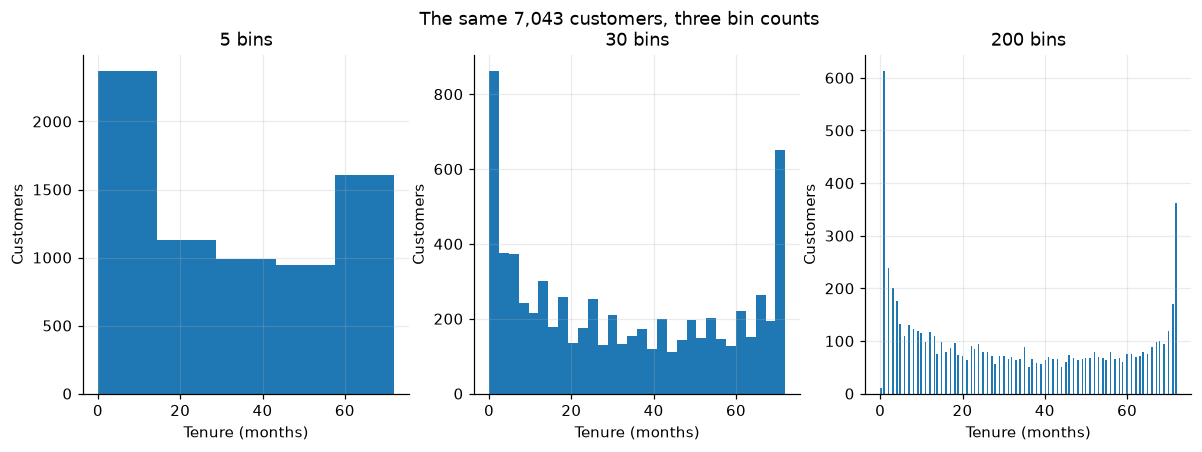

5 bins: one smooth decline.  30 bins: two spikes appear.  200 bins: mostly noise.
The spikes at both ends are real — new customers and long-stayers are genuinely
over-represented. At 5 bins you would never have known they were there.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, n_bins in zip(axes, [5, 30, 200]):
    ax.hist(df["tenure"], bins=n_bins, color=PALETTE[0])
    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Customers")
    ax.set_title(f"{n_bins} bins")

fig.suptitle("The same 7,043 customers, three bin counts")
plt.show()

print("5 bins: one smooth decline.  30 bins: two spikes appear.  200 bins: mostly noise.")
print("The spikes at both ends are real — new customers and long-stayers are genuinely")
print("over-represented. At 5 bins you would never have known they were there.")

A box plot answers a different question: **does this numeric column differ between the two groups?**
The box spans the middle half of the data, the line inside it is the median, and the points beyond
the whiskers are the values matplotlib considers outliers by its own rule.

**Change one thing:** swap `MonthlyCharges` for `tenure` in the cell below. One of the two separates
churners far more sharply than the other. Note which, before Section 2 measures it.

<div dir="rtl" align="right">

يجيب مخطّط الصندوق عن سؤال آخر: **هل يختلف هذا العمود الرقمي بين المجموعتين؟** فالصندوق يغطّي النصف
الأوسط من البيانات، والخط داخله هو الوسيط، والنقاط خارج الشاربين هي ما تعدّه matplotlib قيمًا شاذّة
بقاعدتها الخاصة.

**غيّر شيئًا واحدًا:** استبدل `MonthlyCharges` بـ `tenure` في الخلية أدناه. أحد العمودين يفصل المغادرين
بحدّة أكبر بكثير من الآخر، فلاحظ أيّهما قبل أن يقيسه القسم الثاني.

</div>

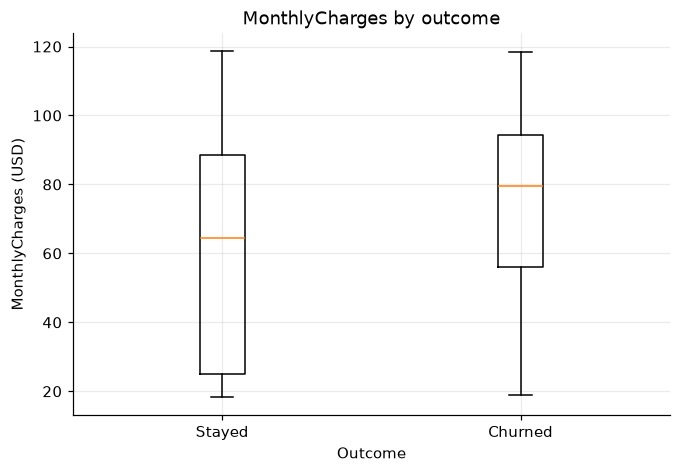

  stayed: median   64.43   IQR   25.10 to   88.40
 churned: median   79.65   IQR   56.15 to   94.20


In [5]:
column = "MonthlyCharges"      # <- change this to "tenure" and re-run

fig, ax = plt.subplots()
groups = [df.loc[df["churn_flag"] == 0, column], df.loc[df["churn_flag"] == 1, column]]
ax.boxplot(groups, tick_labels=["Stayed", "Churned"])
ax.set_xlabel("Outcome")
ax.set_ylabel(f"{column} (USD)")
ax.set_title(f"{column} by outcome")
plt.show()

for name, values in zip(["stayed", "churned"], groups):
    print(f"{name:>8}: median {values.median():7.2f}   IQR "
          f"{values.quantile(0.25):7.2f} to {values.quantile(0.75):7.2f}")

## Section 2 — Core: five charts, five findings  (≈60 min)

Five tasks. Each one is a chart **and** a written sentence. The TA walking the room will ask you to
read the sentence out; "here is a bar chart of contract type" is not a finding, and neither is
"contract type is important".

A finding names a quantity, a direction, and a decision:

> ✅ *Month-to-month customers churn at 42.7% against 2.8% for two-year contracts, so contract
> length belongs in the model and the retention team should be called before renewal, not after.*
>
> ❌ *Contract type correlates with churn.*

Save every chart into `charts/`, and register its `Axes` in `AXES` so the sanity check can read your
labels back.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: خمسة رسوم وخمس نتائج (نحو ٦٠ دقيقة)

خمس مهام، كل واحدة رسم **مع** جملة مكتوبة. وسيطلب منك المساعد في القاعة أن تقرأ الجملة بصوت مسموع؛
فقولك «هذا مخطّط أعمدة لنوع العقد» ليس نتيجة، وكذلك قولك «نوع العقد مهم».

والنتيجة تذكر مقدارًا واتجاهًا وقرارًا:

> ✅ *يغادر أصحاب العقود الشهرية بنسبة ٤٢٫٧٪ مقابل ٢٫٨٪ لعقود السنتين، فطول العقد يستحق مكانًا في
> النموذج، وعلى فريق الاحتفاظ الاتصال قبل التجديد لا بعده.*
>
> ❌ *نوع العقد مرتبط بالمغادرة.*

احفظ كل رسم في مجلّد `charts/`، وسجّل كائن `Axes` الخاص به في `AXES` ليقرأ فحص النتائج تسمياتك.

</div>

### Chart 1 — the target, and the score you have to beat

Before anything else: how many of each class are there? On this dataset that question has a number
attached to it that you will use for the next six weeks.

If 73.5% of customers stayed, then a model that outputs "stayed" for everybody is **73.5% accurate**
and completely useless. That is the number your first accuracy score is competing against, and it is
the reason W1D4 spent a whole session on why accuracy is the wrong metric under imbalance.

<div dir="rtl" align="right">

### الرسم الأول — الهدف، والنتيجة التي عليك التفوّق عليها

قبل أي شيء: كم عدد كل فئة؟ ولهذا السؤال في هذه البيانات رقم ستستخدمه في الأسابيع الستة القادمة.

فإذا بقي ٧٣٫٥٪ من العملاء، فالنموذج الذي يقول «بقي» للجميع **دقّته ٧٣٫٥٪** وهو عديم الفائدة تمامًا. وهذا
هو الرقم الذي تنافسه أول قيمة دقة تحصل عليها، وهو سبب تخصيص الأسبوع الأول اليوم الرابع جلسة كاملة
لبيان أن الدقة مقياس خاطئ عند اختلال توازن الفئات.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Count how many customers are in each class of Churn.
# 2) Draw them as a bar chart — two bars, and put the actual count and the
#    percentage on or beside each one. A reader should not have to squint at an axis.
# 3) Title it with the finding: the majority-class rate IS the score to beat.
# 4) Register the Axes in AXES and save the figure into charts/.
# Search: "matplotlib bar chart annotate value"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html
#
# ١) احسب عدد العملاء في كل فئة من فئتي Churn.
# ٢) ارسمهما مخطّط أعمدة — عمودان، وضع العدد الفعلي والنسبة على كل عمود أو بجانبه.
#    فلا ينبغي للقارئ أن يُدقّق النظر في محور ليعرف الرقم.
# ٣) اجعل العنوان هو النتيجة: فنسبة الفئة الأكبر **هي** النتيجة التي يجب التفوّق عليها.
# ٤) سجّل كائن Axes في AXES واحفظ الشكل في مجلّد charts/.
# ابحث عن: "matplotlib bar chart annotate value"
# ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots()
# TODO: Two bars, with the count and the share written on each.
# مهمة: عمودان، مع كتابة العدد والنسبة على كل واحد.
# TODO: Label both axes with units, and title the chart with the finding.
# مهمة: سمِّ المحورين بوحداتهما، واجعل عنوان الرسم هو النتيجة.
AXES["01_target_balance"] = ax
savefig(fig, "charts/01_target_balance.png")
plt.show()
print(f"baseline accuracy from always predicting the majority class: "
      f"{1 - df['churn_flag'].mean():.1%}")

**Finding 1 — write it here:** _(one sentence. What does the class balance mean for how you will
report a score?)_

<div dir="rtl" align="right">

**النتيجة الأولى — اكتبها هنا:** _(جملة واحدة. ما معنى توازن الفئات هذا لطريقة عرضك للنتيجة؟)_

</div>

### Chart 2 — which numeric column separates the classes?

Yesterday you ranked the numeric columns by how far apart the two groups' means sat, measured in
standard deviations. `tenure` came second at 0.80. Now look at it.

Plot the distribution of the strongest numeric feature for churners and for stayers **on the same
axes**, so the overlap is visible. Overlap is the whole point: two groups can have very different
means and still be almost impossible to tell apart row by row, and a difference in means does not
promise you a usable rule.

<div dir="rtl" align="right">

### الرسم الثاني — أي عمود رقمي يفصل الفئتين؟

رتّبت بالأمس الأعمدة الرقمية بمقدار تباعد متوسطي المجموعتين مقيسًا بالانحرافات المعيارية، وجاء `tenure`
ثانيًا بقيمة ٠٫٨٠. فانظر إليه الآن.

ارسم توزيع أقوى خاصية رقمية للمغادرين وللباقين **على المحاور نفسها** ليكون التداخل مرئيًا. والتداخل هو
المقصود: فقد يختلف متوسط مجموعتين اختلافًا كبيرًا ويبقى التمييز بينهما صفًا صفًا شبه مستحيل، وفرق
المتوسطات لا يضمن لك قاعدة قابلة للاستخدام.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Draw two histograms of `tenure` on ONE Axes — churners and stayers — with
#    alpha below 1 so you can see where they overlap. Add a legend.
# 2) Use density=True, not raw counts: there are three times as many stayers, and
#    on raw counts the churner distribution disappears under theirs.
# 3) Print each group's median so your sentence can quote a number.
# 4) Register the Axes and save the figure.
# Search: "matplotlib hist density alpha legend"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html
#
# ١) ارسم مدرّجين تكراريين لعمود `tenure` على **محاور واحدة**: المغادرون والباقون،
#    بقيمة alpha أقل من واحد ليظهر موضع التداخل. وأضف وسيلة إيضاح.
# ٢) استخدم density=True لا الأعداد الخام: فالباقون ثلاثة أضعاف المغادرين،
#    وبالأعداد الخام يختفي توزيع المغادرين تحت توزيعهم.
# ٣) اطبع وسيط كل مجموعة ليكون في جملتك رقم تستشهد به.
# ٤) سجّل كائن Axes واحفظ الشكل.
# ابحث عن: "matplotlib hist density alpha legend"
# ────────────────────────────────────────────────────────────────────

FEATURE = "tenure"
fig, ax = plt.subplots()
# TODO: Two overlaid density histograms of FEATURE, one per outcome, with a legend.
# مهمة: مدرّجان تكراريان متراكبان بالكثافة لعمود FEATURE، واحد لكل نتيجة، مع وسيلة إيضاح.
# TODO: Axis labels with units, and a title stating what the overlap means.
# مهمة: تسميات المحاور بوحداتها، وعنوان يذكر معنى التداخل.
AXES["02_feature_by_outcome"] = ax
savefig(fig, "charts/02_feature_by_outcome.png")
plt.show()
# TODO: Print the median FEATURE for each group.
# مهمة: اطبع وسيط عمود FEATURE لكل مجموعة.

**Finding 2 — write it here:** _(one sentence. Quote both medians, and say what the overlap costs a
rule based on this column alone.)_

<div dir="rtl" align="right">

**النتيجة الثانية — اكتبها هنا:** _(جملة واحدة. اذكر الوسيطين، وقل ما يكلّفه التداخل قاعدةً تعتمد على
هذا العمود وحده.)_

</div>

### Chart 3 — the heatmap, and the column you did not need

A correlation heatmap shows every pairwise correlation at once. Its job here is not to find what
predicts churn — a single column rarely does that on its own. Its job is to find **columns that
duplicate each other**, because two near-identical features make a linear model's coefficients
unstable and its explanations meaningless: the model splits the credit between them arbitrarily, and
the split changes every time you refit.

Two columns in this table correlate above **0.99**. One of them you engineered yesterday.

Look at the matrix before you read the next markdown cell.

<div dir="rtl" align="right">

### الرسم الثالث — الخريطة الحرارية، والعمود الذي لم تكن بحاجة إليه

تُظهر خريطة الارتباط الحرارية كل ارتباط ثنائي مرة واحدة. ووظيفتها هنا ليست إيجاد ما يتنبّأ بالمغادرة —
فالعمود الواحد نادرًا ما يفعل ذلك وحده — بل إيجاد **الأعمدة التي يكرّر بعضها بعضًا**، لأن خاصيتين شبه
متطابقتين تجعلان معاملات النموذج الخطّي غير مستقرّة وتفسيراته بلا معنى: فالنموذج يوزّع الأثر بينهما
اعتباطًا، ويتغيّر التوزيع في كل مرة تعيد التدريب.

هناك عمودان في هذا الجدول ارتباطهما أعلى من **٠٫٩٩**، وأحدهما هندسته بالأمس.

انظر إلى المصفوفة قبل قراءة خلية الشرح التالية.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Pick the numeric columns worth comparing — tenure, MonthlyCharges,
#    TotalCharges, avg_monthly_spend, contract_months, SeniorCitizen, churn_flag.
# 2) Compute the correlation matrix, then draw it with imshow. Use a diverging
#    colour map centred on zero (vmin=-1, vmax=1) — otherwise -0.9 and +0.9 look alike.
# 3) Write the number into each cell. A heatmap you cannot read the values off is
#    a decoration, and this lab does not accept decoration.
# 4) Print the most correlated pair that is not a column with itself.
# Search: "matplotlib imshow correlation matrix annotate"
#
# ١) اختر الأعمدة الرقمية التي تستحق المقارنة: tenure وMonthlyCharges
#    وTotalCharges وavg_monthly_spend وcontract_months وSeniorCitizen وchurn_flag.
# ٢) احسب مصفوفة الارتباط ثم ارسمها بـ imshow، مع تدرّج لوني متعارض حول الصفر
#    (vmin=-1 وvmax=1) وإلا تشابهت القيمتان -٠٫٩ و+٠٫٩.
# ٣) اكتب الرقم داخل كل خليّة، فالخريطة التي لا تُقرأ قيمها زخرفة،
#    وهذا المعمل لا يقبل الزخرفة.
# ٤) اطبع أعلى زوج مرتبط، مستثنيًا ارتباط العمود بنفسه.
# ابحث عن: "matplotlib imshow correlation matrix annotate"
# ────────────────────────────────────────────────────────────────────

NUMERIC = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend",
           "contract_months", "SeniorCitizen", "churn_flag"]
fig, ax = plt.subplots(figsize=(8, 6.5))
# TODO: Draw the matrix with a diverging colour map fixed to the range -1 to 1.
# مهمة: ارسم المصفوفة بتدرّج لوني متعارض مثبَّت على المدى من -١ إلى ١.
# TODO: Tick labels on both axes, and the correlation written inside every cell.
# مهمة: تسميات على المحورين، وقيمة الارتباط مكتوبة داخل كل خليّة.
# TODO: Label the axes and title the chart with what it found.
# مهمة: سمِّ المحورين واجعل العنوان هو ما وجدته الخريطة.
AXES["03_correlation_heatmap"] = ax
savefig(fig, "charts/03_correlation_heatmap.png")
plt.show()
# TODO: Find and print the most correlated pair of different columns.
# مهمة: اعثر على أعلى زوج مرتبط من عمودين مختلفين واطبعه.

`MonthlyCharges` and `avg_monthly_spend` correlate at **0.996**.

That is not a coincidence and it is not a bug in your code. `avg_monthly_spend` is
`TotalCharges / tenure` — the average bill over a customer's whole life. For almost every customer
in this dataset the bill has barely moved since they signed up, so the lifetime average and this
month's charge are the same number.

The feature you engineered yesterday carries **almost no information you did not already have**. It
was a reasonable hypothesis; the data says no. Keep both and a linear model will split the
coefficient between them arbitrarily, and the "importance" you read off it will be noise.

This is the honest outcome of feature engineering more often than anyone admits, and it is why W2D4
measures each new feature one at a time instead of adding five and hoping.

<div dir="rtl" align="right">

يرتبط العمودان `MonthlyCharges` و`avg_monthly_spend` بمعامل **٠٫٩٩٦**.

وهذه ليست مصادفة ولا خطأً في شيفرتك. فـ `avg_monthly_spend` هو `TotalCharges / tenure`، أي متوسط
الفاتورة على مدّة العميل كلها. ولأن فاتورة معظم العملاء في هذه البيانات لم تكد تتغيّر منذ اشتراكهم، صار
المتوسط على المدّة كلها وفاتورة هذا الشهر رقمًا واحدًا.

فالخاصية التي هندستها بالأمس **لا تحمل تقريبًا أي معلومة لم تكن لديك**. كانت فرضية معقولة، والبيانات
تقول لا. وإذا أبقيت العمودين معًا وزّع النموذج الخطّي المُعامل بينهما اعتباطًا، وصارت «الأهمية» التي
تقرأها منه ضوضاء.

وهذه هي النتيجة الصادقة لهندسة الخصائص أكثر مما يعترف أحد، ولهذا يقيس اليوم الرابع كل خاصية جديدة
واحدة واحدة بدل إضافة خمس والأمل في الأفضل.

</div>

**Finding 3 — write it here:** _(one sentence. Which two columns, what correlation, and which one
would you drop before fitting a linear model?)_

<div dir="rtl" align="right">

**النتيجة الثالثة — اكتبها هنا:** _(جملة واحدة. أي عمودين، وبأي ارتباط، وأيّهما ستحذف قبل تدريب نموذج
خطّي؟)_

</div>

### Chart 4 — churn rate by category, sorted

A count bar chart of a category tells you how common each value is. A **rate** bar chart tells you
which value is dangerous. They are different charts and students confuse them constantly: the largest
group is usually not the riskiest one.

Plot the churn rate for each value of a categorical column, sorted worst first, with the group size
next to each bar. The group size is not decoration — a 60% churn rate over nine customers is a rumour,
not a finding.

Do it for `Contract` first. Then, if you have time, loop over three or four categorical columns and
find which one has the widest spread between its best and worst category.

<div dir="rtl" align="right">

### الرسم الرابع — نسبة المغادرة حسب الفئة، مرتّبة

مخطّط الأعمدة بالأعداد يخبرك عن شيوع كل قيمة، أما مخطّط **النسب** فيخبرك أي قيمة خطِرة. وهما رسمان
مختلفان يخلط الطلاب بينهما دائمًا: فالمجموعة الأكبر ليست عادةً الأخطر.

ارسم نسبة المغادرة لكل قيمة من قيم عمود فئوي، مرتّبة بالأسوأ أولًا، مع حجم المجموعة بجانب كل عمود.
وحجم المجموعة ليس زخرفة: فنسبة مغادرة ٦٠٪ على تسعة عملاء إشاعة لا نتيجة.

ابدأ بعمود `Contract`، ثم إن بقي وقت فمُرّ على ثلاثة أو أربعة أعمدة فئوية وابحث عن العمود الذي بين
أفضل فئاته وأسوئها أوسع فرق.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Group by the category and take the MEAN of churn_flag — that mean is the rate.
#    Take the count in the same aggregation; you need it beside each bar.
# 2) Sort by the rate, worst first, and draw a horizontal bar chart — category
#    names are long and read better on the y axis.
# 3) Write "n = ..." at the end of each bar, and draw the overall churn rate as a
#    vertical reference line so every bar is read against it.
# 4) Register the Axes and save.
# Search: "matplotlib barh axvline annotate"
#
# ١) جمّع حسب العمود الفئوي وخذ **متوسط** churn_flag، فهذا المتوسط هو النسبة.
#    وخذ العدد في التجميع نفسه، فأنت تحتاجه بجانب كل عمود.
# ٢) رتّب حسب النسبة بالأسوأ أولًا، وارسم أعمدة أفقية — فأسماء الفئات طويلة
#    وتُقرأ أفضل على المحور الرأسي.
# ٣) اكتب «n = ...» في نهاية كل عمود، وارسم نسبة المغادرة العامة خطًا رأسيًا مرجعيًا
#    لتُقرأ كل الأعمدة بالنسبة إليه.
# ٤) سجّل كائن Axes واحفظ الشكل.
# ابحث عن: "matplotlib barh axvline annotate"
# ────────────────────────────────────────────────────────────────────

CATEGORY = "Contract"
# TODO: Churn rate and group size per category, worst rate first.
# مهمة: نسبة المغادرة وحجم المجموعة لكل فئة، وأسوأ نسبة أولًا.
fig, ax = plt.subplots()
# TODO: Horizontal bars of the rate, with n = ... at the end of each and the overall rate drawn as a reference line.
# مهمة: أعمدة أفقية للنسبة، مع «n = ...» في نهاية كل عمود ونسبة المغادرة العامة كخط مرجعي.
# TODO: Label the axes and title the chart with the size of the gap you found.
# مهمة: سمِّ المحورين واجعل العنوان هو حجم الفرق الذي وجدته.
AXES["04_churn_by_category"] = ax
savefig(fig, "charts/04_churn_by_category.png")
plt.show()
print(rates.to_string(float_format=lambda v: f"{v:,.3f}"))

**Finding 4 — write it here:** _(one sentence. Name the two extreme categories, their rates, their
group sizes, and the decision this supports.)_

Then the question the chart cannot answer: does a long contract *keep* people, or do people who
already intend to stay *choose* long contracts? Nothing in this bar chart distinguishes those two,
and they imply completely different actions. If you cannot tell from the data, say so in your
sentence — that is the honest version.

<div dir="rtl" align="right">

**النتيجة الرابعة — اكتبها هنا:** _(جملة واحدة. اذكر الفئتين المتطرّفتين ونسبتيهما وحجميهما والقرار
الذي تدعمه.)_

ثم السؤال الذي لا يجيب عنه الرسم: هل العقد الطويل **يُبقي** الناس، أم أن من ينوي البقاء أصلًا هو من
**يختار** العقد الطويل؟ لا شيء في هذا المخطّط يميّز بين الاحتمالين، وهما يقتضيان تصرّفين مختلفين
تمامًا. وإن لم تستطع التمييز من البيانات فقل ذلك في جملتك، فهذه هي الصيغة الصادقة.

</div>

### Chart 5 — two features at once, and the shape of the boundary

Everything so far has looked at one column at a time. A scatter of two numeric columns, coloured by
the target, shows you something one-column charts cannot: **the shape of the region where churners
live.**

Plot `tenure` against `MonthlyCharges`, coloured by outcome. Then ask the question that matters for
next week: could a single straight line separate the two colours?

<div dir="rtl" align="right">

### الرسم الخامس — خاصيّتان معًا، وشكل الحدّ الفاصل

كل ما سبق نظر إلى عمود واحد في المرة. أما رسم الانتشار لعمودين رقميين مع تلوينه بالهدف فيُظهر ما لا
تُظهره رسوم العمود الواحد: **شكل المنطقة التي يسكنها المغادرون**.

ارسم `tenure` مقابل `MonthlyCharges` ملوَّنًا بالنتيجة، ثم اسأل السؤال المهم للأسبوع القادم: هل يستطيع
خط مستقيم واحد فصل اللونين؟

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Scatter tenure on x against MonthlyCharges on y, one colour per outcome.
# 2) 7,043 points overplot badly. Use a small marker size and alpha well below 1,
#    and draw the churners LAST so the minority class is not buried.
# 3) Add a legend, label both axes with their units, and title it with the shape
#    you can see rather than the variable names.
# 4) Register the Axes and save.
# Search: "matplotlib scatter alpha legend by group"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html
#
# ١) ارسم tenure على المحور الأفقي مقابل MonthlyCharges على الرأسي، بلون لكل نتيجة.
# ٢) سبعة آلاف نقطة تتراكب بسوء. فاستخدم حجم علامة صغيرًا وقيمة alpha أقل من واحد بكثير،
#    وارسم المغادرين **أخيرًا** كي لا تُدفن الفئة الأصغر.
# ٣) أضف وسيلة إيضاح، وسمِّ المحورين بوحداتهما، واجعل العنوان هو الشكل الذي ترى
#    لا أسماء المتغيّرات.
# ٤) سجّل كائن Axes واحفظ الشكل.
# ابحث عن: "matplotlib scatter alpha legend by group"
# ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7.5, 5))
# TODO: Scatter the two groups, stayers first and churners on top.
# مهمة: ارسم انتشار المجموعتين، الباقون أولًا والمغادرون فوقهم.
# TODO: Axis labels with units, and a title describing the shape you can see.
# مهمة: تسميات المحاور بوحداتها، وعنوان يصف الشكل الذي ترى.
AXES["05_two_feature_scatter"] = ax
savefig(fig, "charts/05_two_feature_scatter.png")
plt.show()
# TODO: Quantify the corner: the churn rate inside it, against the rate everywhere else.
# مهمة: قِس الزاوية بالأرقام: نسبة المغادرة داخلها مقابل النسبة في بقية الرسم.

The churners are concentrated, but the region is a **corner**, not a half-plane. A single straight
line drawn anywhere on this plot leaves a large amount of both colours on the wrong side — you can
check that by trying: no line through this cloud separates it well.

That is the argument for next week's models. A logistic regression draws exactly one straight
boundary. A decision tree draws axis-aligned rectangles, which is the shape you are looking at, and
W3D1 opens on this chart.

<div dir="rtl" align="right">

المغادرون متمركزون، لكن المنطقة **زاوية** لا نصف مستوٍ. وأي خط مستقيم واحد ترسمه في أي موضع من هذا
الرسم يترك قدرًا كبيرًا من اللونين في الجهة الخاطئة — ويمكنك التحقّق بالمحاولة: فلا خط يمرّ في هذه
السحابة يفصلها فصلًا جيّدًا.

وهذه هي حجّة نماذج الأسبوع القادم. فالانحدار اللوجستي يرسم حدًّا مستقيمًا واحدًا فقط، أما شجرة القرار
فترسم مستطيلات موازية للمحاور، وهو الشكل الذي تنظر إليه، ويبدأ الأسبوع الثالث اليوم الأول بهذا الرسم.

</div>

**Finding 5 — write it here:** _(one sentence. Where do churners concentrate, at what rate, and what
does the shape imply about which model to reach for?)_

<div dir="rtl" align="right">

**النتيجة الخامسة — اكتبها هنا:** _(جملة واحدة. أين يتمركز المغادرون، وبأي نسبة، وما يقتضيه الشكل في
اختيار النموذج؟)_

</div>

## Section 3 — Stretch: make one of them publication quality  (≈30 min)

Open-ended. Lower expectation of completeness — get through the first part, and treat the second as
homework if you run out of time.

Pick your strongest chart and rebuild it as if it were going into a report someone senior will read
without you there to narrate it. That means, concretely:

1. **Axes labelled with units.** "Tenure (months)", not "tenure".
2. **A title that states the finding**, not the variables. "Churn is 15x higher on month-to-month
   contracts" beats "Churn rate by contract type".
3. **A readable palette.** Two or three colours, colour-blind-safe (`aiep.viz.PALETTE` is), and never
   red-versus-green as the only difference between two series.
4. **No decoration.** No third dimension, no gradient fill, no chart junk. Every mark on the figure
   should be carrying information.
5. **Exported at 150 dpi** so it survives being pasted into a document.

Then write the **two sentences you would put underneath it** in that report. The first says what the
chart shows. The second says what should be done about it — or says honestly that the chart does not
support an action, which is a legitimate second sentence and a more common one than students expect.

**Link to your capstone:** your capstone report is graded partly on exactly this. One chart that
changes a reader's mind is worth more than eight that fill a page.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: اجعل أحدها بجودة النشر (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل — أنجز الجزء الأول واعتبر الثاني واجبًا منزليًا إن ضاق الوقت.

اختر أقوى رسومك وأعد بناءه كأنه ذاهب إلى تقرير يقرأه مسؤول كبير دون أن تكون حاضرًا لتشرحه. وهذا يعني
تحديدًا:

١. **محاور مُسمّاة بوحداتها.** «Tenure (months)» لا «tenure».
٢. **عنوان يذكر النتيجة** لا المتغيّرات. فقولك «المغادرة أعلى بخمسة عشر ضعفًا في العقود الشهرية» أفضل
   من «نسبة المغادرة حسب نوع العقد».
٣. **تدرّج لوني مقروء.** لونان أو ثلاثة، آمنة لعمى الألوان (وقائمة `aiep.viz.PALETTE` كذلك)، ولا يكون
   الأحمر مقابل الأخضر هو الفرق الوحيد بين سلسلتين.
٤. **بلا زخرفة.** لا بُعد ثالث ولا تعبئة متدرّجة ولا حشو. فكل علامة في الشكل يجب أن تحمل معلومة.
٥. **مُصدَّر بدقة ١٥٠ نقطة في البوصة** ليصمد عند لصقه في مستند.

ثم اكتب **الجملتين التي ستضعهما تحته** في ذلك التقرير. الأولى تقول ما يُظهره الرسم، والثانية تقول ما
ينبغي فعله بشأنه — أو تقول بصدق إن الرسم لا يدعم أي تصرّف، وهذه جملة ثانية مشروعة وأكثر شيوعًا مما
يتوقّع الطلاب.

**الصلة بمشروعك:** يُقيَّم تقرير مشروعك على هذا جزئيًا. فرسم واحد يغيّر رأي قارئه أفضل من ثمانية تملأ صفحة.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Rebuild your best chart with a larger figsize, labelled axes with units, and a
#    title that is the finding.
# 2) Add a source note in small text at the bottom — dataset name and row count.
#    A chart with no provenance cannot be checked by the person reading it.
# 3) Save it at 150 dpi into charts/ and confirm the file is on disk.
# 4) Then write your two report sentences in the markdown cell below.
# Search: "matplotlib savefig dpi figtext"
#
# ١) أعد بناء أفضل رسومك بحجم أكبر، ومحاور مُسمّاة بوحداتها، وعنوان هو النتيجة نفسها.
# ٢) أضف ملاحظة مصدر بخط صغير في الأسفل: اسم مجموعة البيانات وعدد الصفوف.
#    فالرسم بلا مصدر لا يستطيع قارئه التحقّق منه.
# ٣) احفظه بدقة ١٥٠ نقطة في البوصة في مجلّد charts/ وتأكّد أن الملف
#    موجود على القرص.
# ٤) ثم اكتب جملتي التقرير في خلية الشرح أدناه.
# ابحث عن: "matplotlib savefig dpi figtext"
# ────────────────────────────────────────────────────────────────────

# TODO: Rebuild your strongest chart to report quality and save it at 150 dpi.
# مهمة: أعد بناء أقوى رسومك بجودة التقارير واحفظه بدقة ١٥٠ نقطة في البوصة.

**Your two report sentences:** _(the first says what the chart shows; the second says what to do
about it — or says honestly that the chart does not support an action.)_

1.
2.

<div dir="rtl" align="right">

**جملتا تقريرك:** _(الأولى تقول ما يُظهره الرسم، والثانية تقول ما ينبغي فعله بشأنه — أو تقول بصدق إن
الرسم لا يدعم أي تصرّف.)_

١.
٢.

</div>

## Save your artefacts

Two things go to disk: the `charts/` directory, and `eda_findings.md` — your five sentences.

Write the findings file in **both languages**, one bullet per chart. This is not busywork: the file
is the thing you will actually reread in week 8 when your capstone report needs a data section, and a
folder of PNGs with no sentences attached is unreadable three weeks later. You will not remember
which chart mattered.

Replace the five placeholder sentences below with your own before you run the cell.

<div dir="rtl" align="right">

## احفظ مخرجاتك

يذهب شيئان إلى القرص: مجلّد `charts/` وملف `eda_findings.md` بجملك الخمس.

اكتب ملف النتائج **بالّلغتين**، بنقطة واحدة لكل رسم. وهذا ليس عملًا زائدًا: فالملف هو ما ستعود إلى
قراءته فعلًا في الأسبوع الثامن حين يحتاج تقرير مشروعك قسمًا عن البيانات، ومجلّد صور بلا جمل مرفقة غير
قابل للقراءة بعد ثلاثة أسابيع، فلن تتذكّر أي رسم كان المهم.

استبدل الجمل الخمس النموذجية أدناه بجملك قبل تشغيل الخلية.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Build a list of five findings. Each one needs an English sentence and an
#    Arabic sentence — the Arabic is a real translation, not a transliteration.
# 2) Every sentence must name a number and a direction. "X is important" is not a
#    finding; "X differs by 15x between these two groups" is.
# 3) Write them to eda_findings.md as markdown bullets, English block first, then
#    the Arabic inside an RTL div.
# 4) Print the file back so you can see what you actually wrote.
# Search: "python pathlib write_text markdown"
#
# ١) ابنِ قائمة من خمس نتائج، لكل واحدة جملة إنجليزية وجملة عربية —
#    والعربية ترجمة حقيقية لا نقلًا للحروف.
# ٢) كل جملة يجب أن تذكر رقمًا واتجاهًا. فقولك «العمود مهم» ليس نتيجة،
#    وقولك «يختلف بخمسة عشر ضعفًا بين هاتين المجموعتين» نتيجة.
# ٣) اكتبها في ملف eda_findings.md نقاطًا بصيغة ماركداون، الإنجليزية أولًا ثم
#    العربية داخل قسم باتجاه من اليمين إلى اليسار.
# ٤) اطبع الملف بعد كتابته لترى ما كتبته فعلًا.
# ابحث عن: "python pathlib write_text markdown"
# ────────────────────────────────────────────────────────────────────

# TODO: Replace these five with YOUR findings — each naming a number and a direction.
# مهمة: استبدل هذه الخمس بنتائجك، وكل واحدة تذكر رقمًا واتجاهًا.
# TODO: Write the findings to eda_findings.md, English then Arabic in an RTL div.
# مهمة: اكتب النتائج في ملف eda_findings.md، الإنجليزية ثم العربية في قسم من اليمين إلى اليسار.
print(f"Saved {findings_path}")
print(f"charts on disk: {sorted(p.name for p in CHARTS.glob('*.png'))}")

## Sanity check

Run this last. Every check that fails tells you what to fix and why.

Two of these read your figures back off the `Axes` objects rather than trusting that you labelled
them. An unlabelled axis is a bug, and this is where the lab says so.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

واثنان من هذه الفحوصات يقرأان أشكالك من كائنات `Axes` نفسها بدل الوثوق بأنك سمّيتها. فالمحور غير
المُسمّى عيب، وهنا يقول المعمل ذلك.

</div>

In [ ]:
# --- Sanity checks ----------------------------------------------------------------

png_files = sorted(CHARTS.glob("0[1-5]_*.png"))

check(len(png_files) == 5,
      f"the five core charts should be saved in charts/, found {len(png_files)}: "
      f"{[p.name for p in png_files]}",
      f"يجب حفظ الرسوم الخمسة الأساسية في مجلّد charts/، والموجود {len(png_files)}: "
      f"{[p.name for p in png_files]}")

# Read every PNG back and check its real pixel size. A figure saved at default dpi from a
# tiny figsize is unreadable in a report, and nothing in the notebook output shows that.
sizes = {p.name: plt.imread(p).shape[:2] for p in png_files}
too_small = {name: shape for name, shape in sizes.items() if shape[0] < 600 or shape[1] < 800}

check(not too_small,
      f"every chart should be at least 800x600 pixels — too small: {too_small}",
      f"يجب أن يكون كل رسم بحجم ٨٠٠×٦٠٠ بكسل على الأقل — والصغيرة: {too_small}")

check(len(AXES) == 5,
      f"all five charts should be registered in AXES, got {len(AXES)}: {sorted(AXES)}",
      f"يجب تسجيل الرسوم الخمسة في AXES، والمُسجَّل {len(AXES)}: {sorted(AXES)}")

unlabelled = [name for name, ax in AXES.items()
              if not ax.get_xlabel().strip() or not ax.get_ylabel().strip()]
check(not unlabelled,
      f"every chart needs a non-empty label on BOTH axes — missing on: {unlabelled}",
      f"كل رسم يحتاج تسمية غير فارغة على **المحورين** — والناقص في: {unlabelled}")

untitled = [name for name, ax in AXES.items() if len(ax.get_title().strip()) < 15]
check(not untitled,
      f"every chart needs a title that states a finding, not a variable name — too short "
      f"or missing on: {untitled}",
      f"كل رسم يحتاج عنوانًا يذكر نتيجة لا اسم متغيّر — والقصير أو الناقص في: {untitled}")

findings_file = ARTEFACT_DIR / "eda_findings.md"
bullets = [line for line in findings_file.read_text(encoding="utf-8").splitlines()
           if line.startswith("- ") and len(line) > 30] if findings_file.exists() else []

check(len(bullets) >= 5,
      f"eda_findings.md should have at least 5 substantive bullets, found {len(bullets)}",
      f"يجب أن يحتوي ملف eda_findings.md خمس نقاط جوهرية على الأقل، والموجود {len(bullets)}")

check(any(any(ch in line for ch in "٠١٢٣٤٥٦٧٨٩") or any(ch.isdigit() for ch in line)
          for line in bullets),
      "at least one finding must quote a number — a finding without a quantity is an opinion",
      "يجب أن تذكر نتيجة واحدة على الأقل رقمًا — فالنتيجة بلا مقدار رأي لا نتيجة")

report()

## What's next

Tomorrow (**W2D3**) you leave this dataset for one that is genuinely broken: missing values in three
different patterns, dates in four formats, duplicated rows, fourteen spellings of five cities, and one
column that leaks the answer. You will find that column the same way you found the duplicate pair
today — off a correlation heatmap.

<div dir="rtl" align="right">

## ماذا بعد

غدًا (**الأسبوع ٢ اليوم ٣**) تترك هذه البيانات إلى بيانات معطوبة فعلًا: قيم مفقودة بثلاثة أنماط مختلفة،
وتواريخ بأربع صيغ، وصفوف مكرّرة، وأربع عشرة تهجئة لخمس مدن، وعمود واحد يُسرّب الإجابة. وستجد ذلك العمود
بالطريقة نفسها التي وجدت بها الزوج المكرّر اليوم: من خريطة الارتباط الحرارية.

</div>